In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip -q "/content/drive/MyDrive/ecg_dataset/gwbz3fsgp8-2.zip" -d /content/ecg_data
!find /content/ecg_data -maxdepth 3 -type d

/content/ecg_data
/content/ecg_data/ECG Images of Patient that have abnormal heartbeat (233x12=2796)
/content/ecg_data/ECG Images of Patient that have History of MI (172x12=2064)
/content/ecg_data/ECG Images of Myocardial Infarction Patients (240x12=2880)
/content/ecg_data/Normal Person ECG Images (284x12=3408)


In [3]:
import os
mi_folder = "/content/ecg_data/ECG Images of Myocardial Infarction Patients (240x12=2880)"
files_in_folder = os.listdir(mi_folder)
print("Total files:", len(files_in_folder))
print("Sample filenames:", files_in_folder[:10])

Total files: 239
Sample filenames: ['MI(54).jpg', 'MI(174).jpg', 'MI(65).jpg', 'MI(108).jpg', 'MI(93).jpg', 'MI(91).jpg', 'MI(38).jpg', 'MI(36).jpg', 'MI(204).jpg', 'MI(190).jpg']


In [4]:
import os, shutil, random
from pathlib import Path

random.seed(42)

SOURCE_ROOT = "/content/ecg_data"
CLEAN_ROOT = "/content/ecg_clean"

class_map = {
    "ECG Images of Patient that have abnormal heartbeat (233x12=2796)": "abnormal",
    "ECG Images of Patient that have History of MI (172x12=2064)": "history_mi",
    "ECG Images of Myocardial Infarction Patients (240x12=2880)": "mi",
    "Normal Person ECG Images (284x12=3408)": "normal"
}

for split in ["train", "test"]:
    for cls in class_map.values():
        os.makedirs(f"{CLEAN_ROOT}/{split}/{cls}", exist_ok=True)

for orig_name, clean_name in class_map.items():
    src_dir = os.path.join(SOURCE_ROOT, orig_name)
    files = os.listdir(src_dir)
    random.shuffle(files)

    split_idx = int(0.8 * len(files))  # 80/20 train/test
    train_files, test_files = files[:split_idx], files[split_idx:]

    for f in train_files:
        shutil.copy(os.path.join(src_dir, f), f"{CLEAN_ROOT}/train/{clean_name}/{f}")
    for f in test_files:
        shutil.copy(os.path.join(src_dir, f), f"{CLEAN_ROOT}/test/{clean_name}/{f}")

    print(f"{clean_name}: {len(train_files)} train, {len(test_files)} test")

abnormal: 186 train, 47 test
history_mi: 137 train, 35 test
mi: 191 train, 48 test
normal: 227 train, 57 test


In [5]:
import torch, torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import f1_score, classification_report
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(3),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

train_ds = datasets.ImageFolder("/content/ecg_clean/train", transform=train_transform)
test_ds = datasets.ImageFolder("/content/ecg_clean/test", transform=test_transform)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=16)

print("Classes:", train_ds.classes)
print("Train size:", len(train_ds), "| Test size:", len(test_ds))

Using device: cuda
Classes: ['abnormal', 'history_mi', 'mi', 'normal']
Train size: 741 | Test size: 187


In [6]:
model = models.resnet18(weights='IMAGENET1K_V1')
model.fc = nn.Linear(model.fc.in_features, len(train_ds.classes))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 82.3MB/s]


In [7]:
def evaluate(loader):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            out = model(x).argmax(dim=1).cpu().numpy()
            preds.extend(out)
            labels.extend(y.numpy())
    return f1_score(labels, preds, average='macro'), preds, labels

EPOCHS = 15
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)

    test_f1, _, _ = evaluate(test_loader)
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {total_loss/len(train_ds):.4f} | Test F1: {test_f1:.4f}")

Epoch 1/15 | Loss: 0.6862 | Test F1: 0.8784
Epoch 2/15 | Loss: 0.2787 | Test F1: 0.9054
Epoch 3/15 | Loss: 0.1527 | Test F1: 0.9206
Epoch 4/15 | Loss: 0.1511 | Test F1: 0.9373
Epoch 5/15 | Loss: 0.0760 | Test F1: 0.9265
Epoch 6/15 | Loss: 0.0701 | Test F1: 0.9226
Epoch 7/15 | Loss: 0.0869 | Test F1: 0.7987
Epoch 8/15 | Loss: 0.0751 | Test F1: 0.9398
Epoch 9/15 | Loss: 0.1169 | Test F1: 0.9428
Epoch 10/15 | Loss: 0.0742 | Test F1: 0.9475
Epoch 11/15 | Loss: 0.0631 | Test F1: 0.9641
Epoch 12/15 | Loss: 0.0401 | Test F1: 0.9701
Epoch 13/15 | Loss: 0.0460 | Test F1: 0.9582
Epoch 14/15 | Loss: 0.0652 | Test F1: 0.9668
Epoch 15/15 | Loss: 0.0671 | Test F1: 0.9635


In [8]:
best_f1 = 0
best_state = None

EPOCHS = 15
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)

    test_f1, preds, labels = evaluate(test_loader)
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {total_loss/len(train_ds):.4f} | Test F1: {test_f1:.4f}")

    if test_f1 > best_f1:
        best_f1 = test_f1
        best_state = model.state_dict()

print(f"\nBest Test F1: {best_f1:.4f}")
model.load_state_dict(best_state)

test_f1, preds, labels = evaluate(test_loader)
print(classification_report(labels, preds, target_names=train_ds.classes))

torch.save(model.state_dict(), 'model_ecg_image_best.pth')

Epoch 1/15 | Loss: 0.0360 | Test F1: 0.9409
Epoch 2/15 | Loss: 0.0266 | Test F1: 0.9639
Epoch 3/15 | Loss: 0.0312 | Test F1: 0.9455
Epoch 4/15 | Loss: 0.0305 | Test F1: 0.9417
Epoch 5/15 | Loss: 0.0377 | Test F1: 0.9502
Epoch 6/15 | Loss: 0.0805 | Test F1: 0.9634
Epoch 7/15 | Loss: 0.0652 | Test F1: 0.9379
Epoch 8/15 | Loss: 0.0468 | Test F1: 0.9487
Epoch 9/15 | Loss: 0.0176 | Test F1: 0.9635
Epoch 10/15 | Loss: 0.0105 | Test F1: 0.9701
Epoch 11/15 | Loss: 0.0135 | Test F1: 0.9524
Epoch 12/15 | Loss: 0.0067 | Test F1: 0.9573
Epoch 13/15 | Loss: 0.0152 | Test F1: 0.9537
Epoch 14/15 | Loss: 0.0043 | Test F1: 0.9573
Epoch 15/15 | Loss: 0.0026 | Test F1: 0.9573

Best Test F1: 0.9701
              precision    recall  f1-score   support

    abnormal       0.92      0.94      0.93        47
  history_mi       0.94      0.89      0.91        35
          mi       1.00      1.00      1.00        48
      normal       0.98      1.00      0.99        57

    accuracy                           0

In [9]:
import shutil, json

# Save model
shutil.copy('model_ecg_image_best.pth', '/content/drive/MyDrive/ecg_dataset/model_ecg_image_best.pth')

# Save class order — critical, you'll need this exact order later for inference
class_mapping = {i: cls for i, cls in enumerate(train_ds.classes)}
with open('/content/drive/MyDrive/ecg_dataset/class_mapping.json', 'w') as f:
    json.dump(class_mapping, f, indent=2)

print("Model saved to Drive")
print("Class mapping:", class_mapping)

Model saved to Drive
Class mapping: {0: 'abnormal', 1: 'history_mi', 2: 'mi', 3: 'normal'}


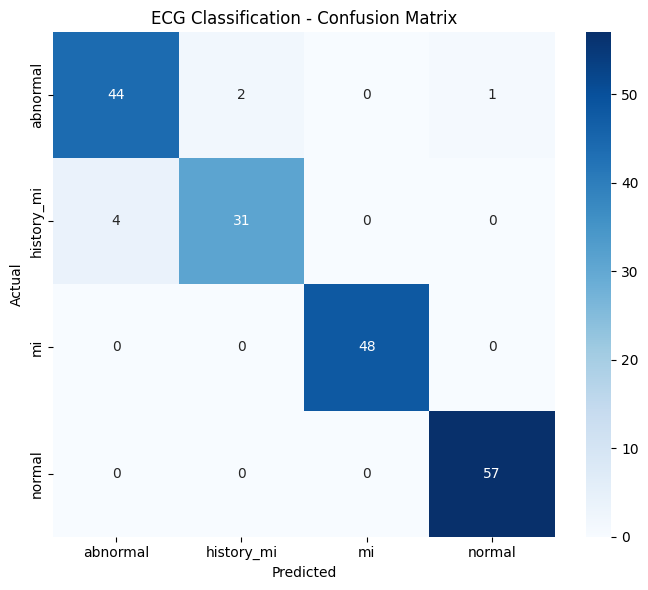

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_ds.classes, yticklabels=train_ds.classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('ECG Classification - Confusion Matrix')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ecg_dataset/confusion_matrix.png', dpi=150)
plt.show()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 61.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


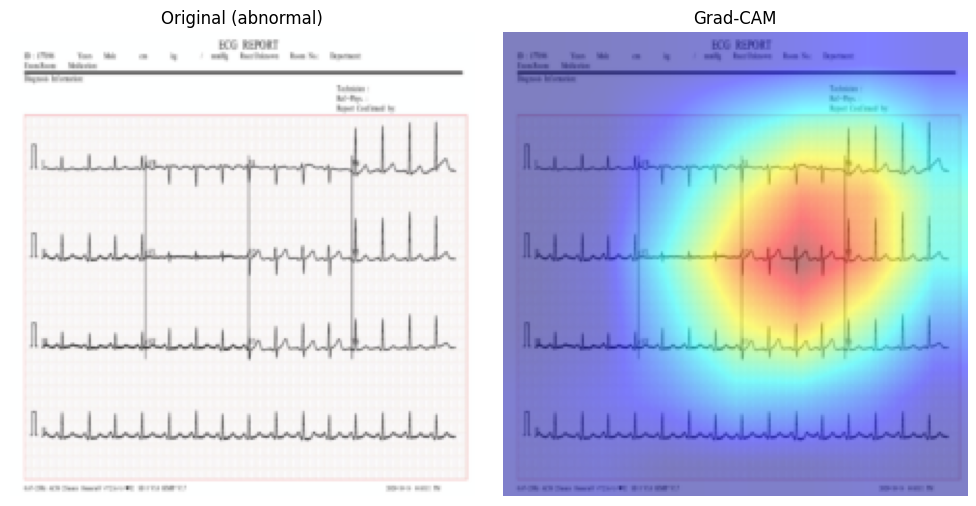

In [11]:
!pip install grad-cam -q

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import torch

model.eval()
target_layer = [model.layer4[-1]]  # last conv block of ResNet18

cam = GradCAM(model=model, target_layers=target_layer)

# grab one test image to visualize
sample_img, sample_label = test_ds[0]
input_tensor = sample_img.unsqueeze(0).to(device)

grayscale_cam = cam(input_tensor=input_tensor)[0]

# unnormalize the image for display
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_np = sample_img.permute(1,2,0).numpy()
img_np = std * img_np + mean
img_np = np.clip(img_np, 0, 1)

visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img_np)
plt.title(f"Original ({train_ds.classes[sample_label]})")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(visualization)
plt.title("Grad-CAM")
plt.axis('off')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ecg_dataset/gradcam_sample.png', dpi=150)
plt.show()

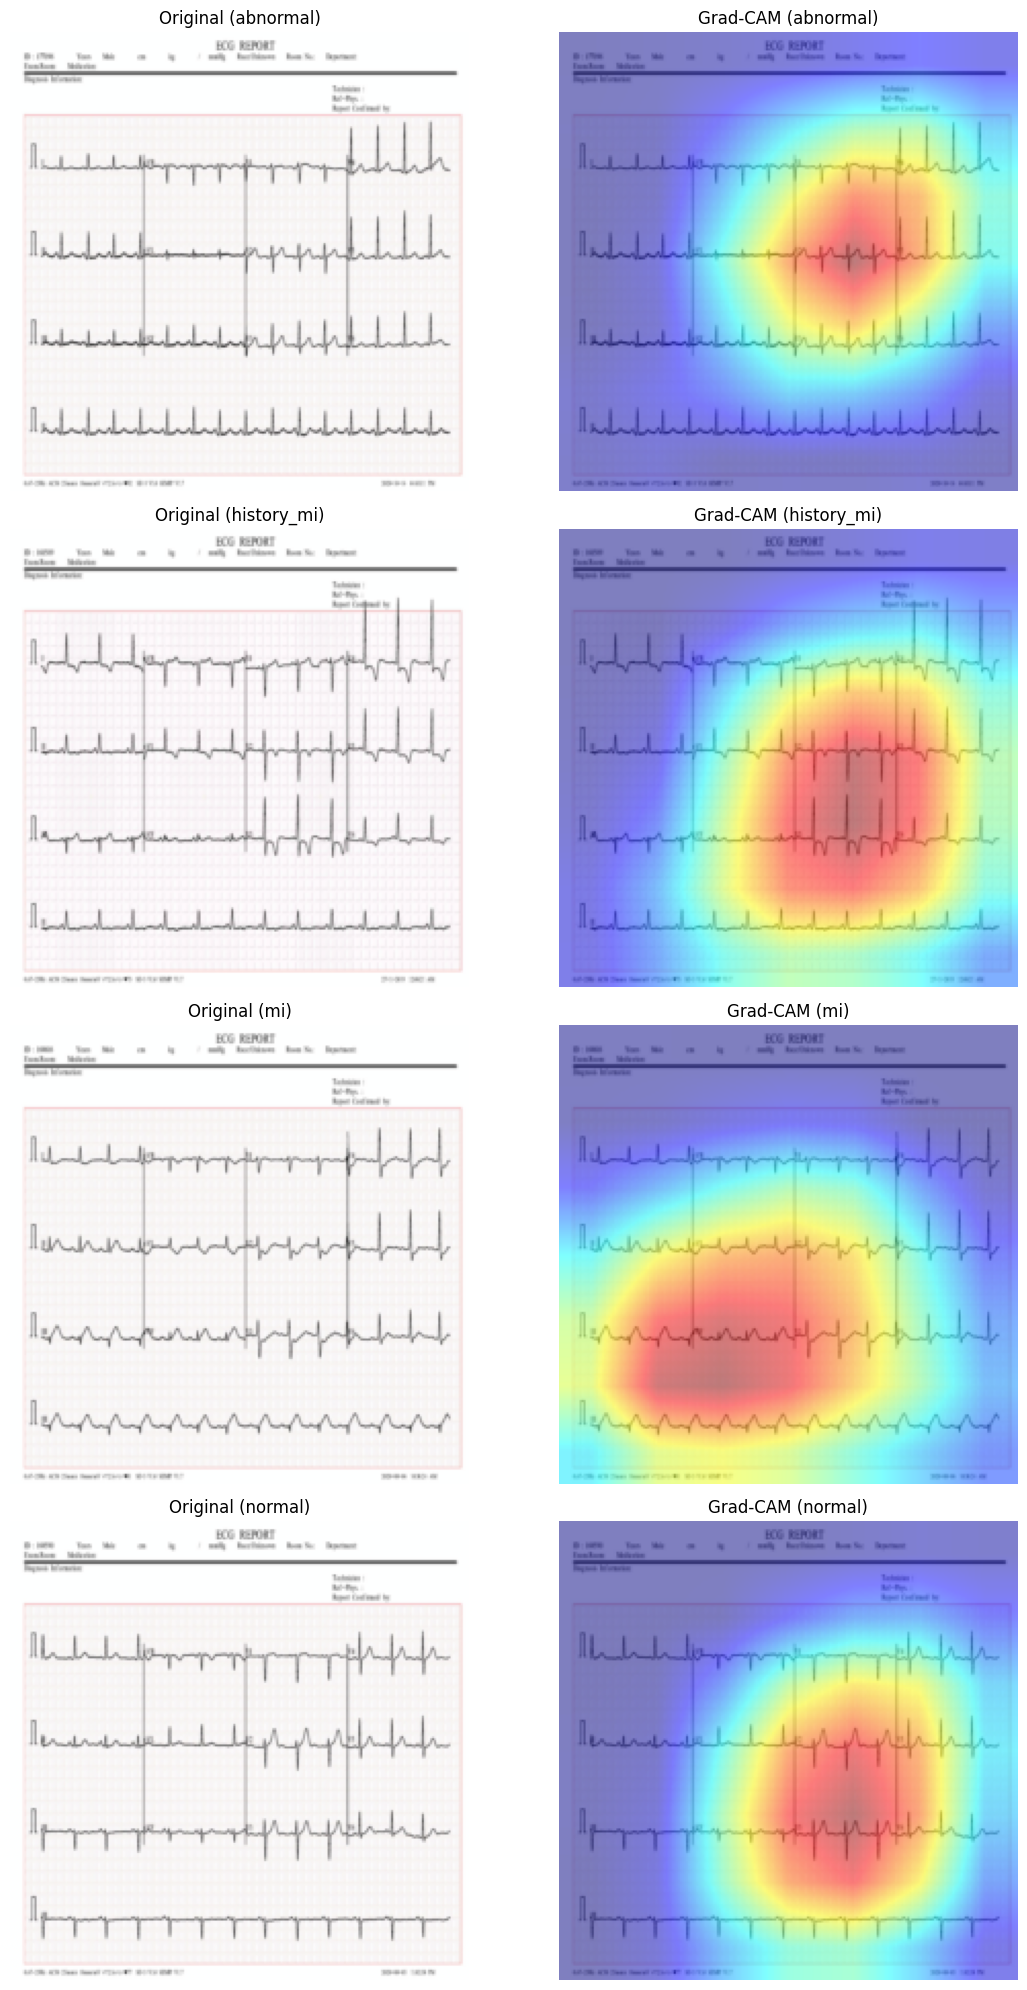

In [12]:
fig, axes = plt.subplots(4, 2, figsize=(12, 20))

# find one test sample per class
class_samples = {}
for idx in range(len(test_ds)):
    _, label = test_ds[idx]
    cls_name = train_ds.classes[label]
    if cls_name not in class_samples:
        class_samples[cls_name] = idx
    if len(class_samples) == 4:
        break

for row, (cls_name, idx) in enumerate(class_samples.items()):
    img, label = test_ds[idx]
    input_tensor = img.unsqueeze(0).to(device)
    grayscale_cam = cam(input_tensor=input_tensor)[0]

    img_np = img.permute(1,2,0).numpy()
    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)
    visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    axes[row, 0].imshow(img_np)
    axes[row, 0].set_title(f"Original ({cls_name})")
    axes[row, 0].axis('off')

    axes[row, 1].imshow(visualization)
    axes[row, 1].set_title(f"Grad-CAM ({cls_name})")
    axes[row, 1].axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ecg_dataset/gradcam_all_classes.png', dpi=150)
plt.show()

In [13]:
import torch.nn.functional as F

def predict_ecg(image_path, model, class_mapping, transform):
    from PIL import Image
    img = Image.open(image_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(input_tensor)
        probs = F.softmax(logits, dim=1).cpu().numpy()[0]

    pred_idx = int(np.argmax(probs))

    result = {
        "modality": "ecg",
        "prediction": class_mapping[pred_idx],
        "confidence": float(probs[pred_idx]),
        "all_probabilities": {class_mapping[i]: float(p) for i, p in enumerate(probs)}
    }
    return result

# test it on one sample image
import glob
test_image_path = glob.glob("/content/ecg_clean/test/mi/*.jpg")[0]
result = predict_ecg(test_image_path, model, class_mapping, test_transform)
print(json.dumps(result, indent=2))

{
  "modality": "ecg",
  "prediction": "mi",
  "confidence": 0.999921441078186,
  "all_probabilities": {
    "abnormal": 7.674837434024084e-06,
    "history_mi": 1.8903350792243145e-05,
    "mi": 0.999921441078186,
    "normal": 5.201949898037128e-05
  }
}


In [14]:
inference_script = '''
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models
from PIL import Image
import numpy as np
import json

IMG_SIZE = 224
CLASS_MAPPING = {0: 'abnormal', 1: 'history_mi', 2: 'mi', 3: 'normal'}

def load_model(model_path, device='cpu'):
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, len(CLASS_MAPPING))
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    return model

def get_transform():
    return transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])

def predict_ecg(image_path, model, device='cpu'):
    transform = get_transform()
    img = Image.open(image_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(input_tensor)
        probs = F.softmax(logits, dim=1).cpu().numpy()[0]

    pred_idx = int(np.argmax(probs))

    return {
        "modality": "ecg",
        "prediction": CLASS_MAPPING[pred_idx],
        "confidence": float(probs[pred_idx]),
        "all_probabilities": {CLASS_MAPPING[i]: float(p) for i, p in enumerate(probs)}
    }

if __name__ == "__main__":
    import sys
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = load_model("model_ecg_image_best.pth", device)
    result = predict_ecg(sys.argv[1], model, device)
    print(json.dumps(result, indent=2))
'''

with open('/content/drive/MyDrive/ecg_dataset/ecg_inference.py', 'w') as f:
    f.write(inference_script)

print("Saved ecg_inference.py to Drive")

Saved ecg_inference.py to Drive
